<a href="https://colab.research.google.com/github/sbednarz/ModelowanieProcesowBiotechnologicznych2026/blob/main/kinetyka_bioproces%C3%B3w/05_semibatch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Procesy półciągłe (feed-batch, semibatch). Różniczkowe bilanse masy.

## Dlaczego fed-batch jest ważny w biotechnologii

**1. Kontrola szybkości wzrostu → unikanie limitacji tlenowej.**
W batch OUR rośnie wykładniczo i przekracza zdolność transferu tlenu bioreaktora. Fed-batch ogranicza μ przez limitację substratową — komórki rosną wolniej i zużywają tlen w tempie, które bioreaktor zapewni.

**2. Unikanie metabolizmu overflow (Crabtree / acetate overflow).**
E. coli przy nadmiarze glukozy produkuje kwas octowy, a S. cerevisiae etanol — nawet w obecności tlenu. Fed-batch utrzymuje stężenie glukozy bliskie zeru, wymuszając metabolizm respiracyjny z maksymalnym Y_XS.

**3. Osiąganie wysokich gęstości komórkowych (HCDF).**
W batch ilość biomasy jest ograniczona przez substrat w medium — np. 20 g/L glukozy → ~10 g/L biomasy. Fed-batch pozwala dozować skoncentrowany feed (30–50% cukru) i osiągać 50–150 g/L biomasy.

**4. Rozdzielenie fazy wzrostu i produkcji.**
Wiele procesów wymaga najpierw szybkiego namnożenia biomasy, a potem spowolnienia wzrostu i indukcji metabolitów (np. IPTG). Zmiana profilu zasilania z eksponencjalnego na stały naturalnie obniża μ i przełącza komórki w tryb produkcji.

**5. Unikanie inhibicji substratowej i stresu osmotycznego.**
Wysokie stężenia substratu (>200 g/L) hamują wiele organizmów przez ciśnienie osmotyczne lub toksyczność (np. metanol, inhibitory z hydrolizatów). Fed-batch pozwala dozować substrat stopniowo, utrzymując go poniżej progu toksyczności.

**6. Przewaga nad chemostatem w praktyce.**
Chemostat daje niski stężenie bioproduktu (drogi downstream), grozi niestabilnością genetyczną (mutanty wypierają szczep produkcyjny) i wymaga sterylności przez tygodnie. Fed-batch łączy kontrolę metaboliczną chemostatu z wysokimi stężeniami jak w batch — dlatego ~80% bioprocesów przemysłowych to fed-batch.

## 1. Brak reakcji/bioprocesu - najprostszy przypadek

$$\text{Akumulacja} = \text{Wlot} - \text{Wylot}$$

$$\frac{dm}{dt} = \frac{d(\rho V)}{dt} = \rho F_{in} - \rho F_{out}$$

Gdy gęstość $\rho$ jest stała i jednakowa na wlocie i wylocie:

$$\frac{dV}{dt} = F_{in} - F_{out}$$

To jest najprostszy model semibatch — **bez reakcji chemicznych i bez bioprocesów**.

Time, min
[ 0.          1.2244898   2.44897959  3.67346939  4.89795918  6.12244898
  7.34693878  8.57142857  9.79591837 11.02040816 12.24489796 13.46938776
 14.69387755 15.91836735 17.14285714 18.36734694 19.59183673 20.81632653
 22.04081633 23.26530612 24.48979592 25.71428571 26.93877551 28.16326531
 29.3877551  30.6122449  31.83673469 33.06122449 34.28571429 35.51020408
 36.73469388 37.95918367 39.18367347 40.40816327 41.63265306 42.85714286
 44.08163265 45.30612245 46.53061224 47.75510204 48.97959184 50.20408163
 51.42857143 52.65306122 53.87755102 55.10204082 56.32653061 57.55102041
 58.7755102  60.        ]
V(t), L
[  0.          11.02040816  22.04081633  33.06122449  44.08163265
  55.10204082  66.12244898  77.14285714  88.16326531  99.18367347
 110.20408163 121.2244898  132.24489796 143.26530612 154.28571429
 165.30612245 176.32653061 187.34693878 198.36734694 209.3877551
 220.40816327 231.42857143 242.44897959 253.46938776 264.48979592
 275.51020408 286.53061224 297.55102041 308

Text(0, 0.5, 'V, L')

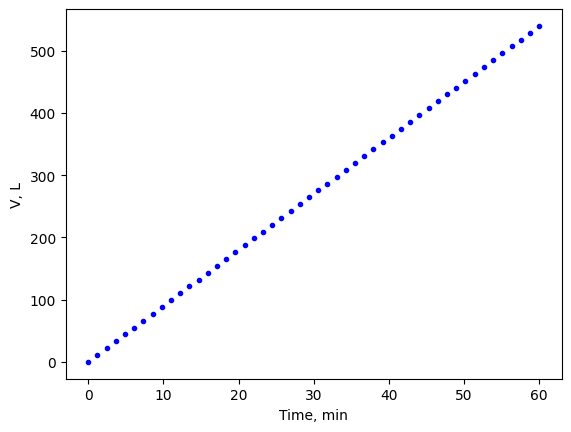

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint

# model = mass balance = ODE (or ODEs)
def model(y, t):
    V = y[0]
    dVdt = Fin - Fout
    return [dVdt]

Fin = 10 #L/min
Fout = 1 #L/min
t = np.linspace(0,60) # 0 - 60 min

ic = [0] # initial conditions: V at t=0 -> V0=0

results = odeint(model, ic, t)
V = results[:,0]
print("Time, min")
print(t)
print("V(t), L")
print(V) # V(t)

plt.plot(t,V, 'b.')
plt.xlabel('Time, min')
plt.ylabel('V, L')

### Zadanie 1

Zbiornik zawiera początkowo $V_0 = 400\ \text{L}$ cieczy, $F_{in} = 1\ \text{L/min}$ i $F_{out} = 10\ \text{L/min}$. Zasymulować ten scenariusz.

In [ ]:
### Tutaj kod

### Zadanie 2

W zbiorniku jest $m = 5\ \text{kg}$ soli o masie molowej $M = 150\ \text{kg/kmol}$.
Dolewamy rozpuszczalnik z szybkością $F_{in} = 0.5\ \text{m}^3/\text{h}$ (brak odpływu).
Narysuj $V(t)$ i stężenie molowe $C(t)$ w czasie $0 \leq t \leq 12\ \text{h}$.

**Model:**

Ilość moli soli jest stała (sól jest już w zbiorniku, nie wchodzi z wlotem):

$$n = \frac{m}{M} = \text{const}, \qquad \frac{dV}{dt} = F_{in}, \qquad C(t) = \frac{n}{V(t)}$$

**Wskazówka:** Obliczenia PO całkowaniu ODE.

**Kontekst bio** To jest analogia do rozcieńczania biomasy w fed-batchu —
masa substancji stała, objętość rośnie → stężenie maleje.


In [ ]:
### Tutaj kod

### Zadanie 3


Wyparka zawiera początkowo $V_0 = 100\ \text{L}$ roztworu substancji A o stężeniu $C_0 = 1\ \text{mol/L}$.
Szybkość odparowania rozpuszczalnika: $\dot{V}_{out} = 50\ \text{L/h}$.
Narysuj $V(t)$ i $[A](t)$ w czasie $0 \leq t \leq 1\ \text{h}$.

**Wskazówki:**
- Substancja A nie paruje — jej ilość moli $n_A = C_0 \cdot V_0 = \text{const}$
- Model ODE: $\frac{dV}{dt} = -\dot{V}_{out}$
- Stężenie: $[A](t) = n_A / V(t)$

In [ ]:
### Tutaj kod

## 2. Semibatch  i reakcja chemiczna

Reakcja drugiego rzędu: $r = k \cdot [A] \cdot [B]$.
Składnik A jest dozowany do reaktora zawierającego B.

A + B → C


W reaktorze semibatch (półciągłym):
- **B** jest na starcie w reaktorze — nie dolewamy go
- **A** jest dozowany ze stałym przepływem $F$ i stężeniem $A_{in}$
- **C** powstaje w reaktorze i się kumuluje
- **objętość rośnie** — efekt rozcieńczenia działa na **wszystkie** składniki obecne w reaktorze (A, B i C).

Każdy składnik ma swój bilans masy. Ogólna forma dla składnika $i$:

$$\frac{d(c_i \cdot V)}{dt} = F \cdot c_{i,in} - r_i \cdot V$$


Po rozwinięciu pochodnej iloczynu $\frac{d(c_i V)}{dt} = V \frac{dc_i}{dt} + c_i \frac{dV}{dt}$
i podstawieniu $\frac{dV}{dt} = F$:

$$\frac{dc_i}{dt} = \frac{F}{V}(c_{i,in} - c_i) \pm r_i$$



## Układ równań (model)

Zmienne stanu: $[A](t)$, $[B](t)$, $[C](t)$, $V(t)$

Kinetyka: $r = k \cdot [A] \cdot [B]$ &nbsp; [mol·L⁻¹·min⁻¹]

$$\frac{d[A]}{dt} = \frac{F}{V}(A_{in} - [A]) - k[A][B]$$

$$\frac{d[B]}{dt} = \frac{F}{V}(0 - [B]) - k[A][B]$$

$$\frac{d[C]}{dt} = \frac{F}{V}(0 - [C]) + k[A][B]$$

$$\frac{dV}{dt} = F$$

Każde równanie ma dwa człony:
- $\frac{F}{V}$ — efekt rozcieńczenia
- $\pm k[A][B]$ — reakcja (A i B zanikają, C powstaje)

Dla B: $c_{B,in} = 0$ bo B nie jest w zasilaniu — człon wlotowy to samo rozcieńczenie: $-\frac{F}{V}[B]$


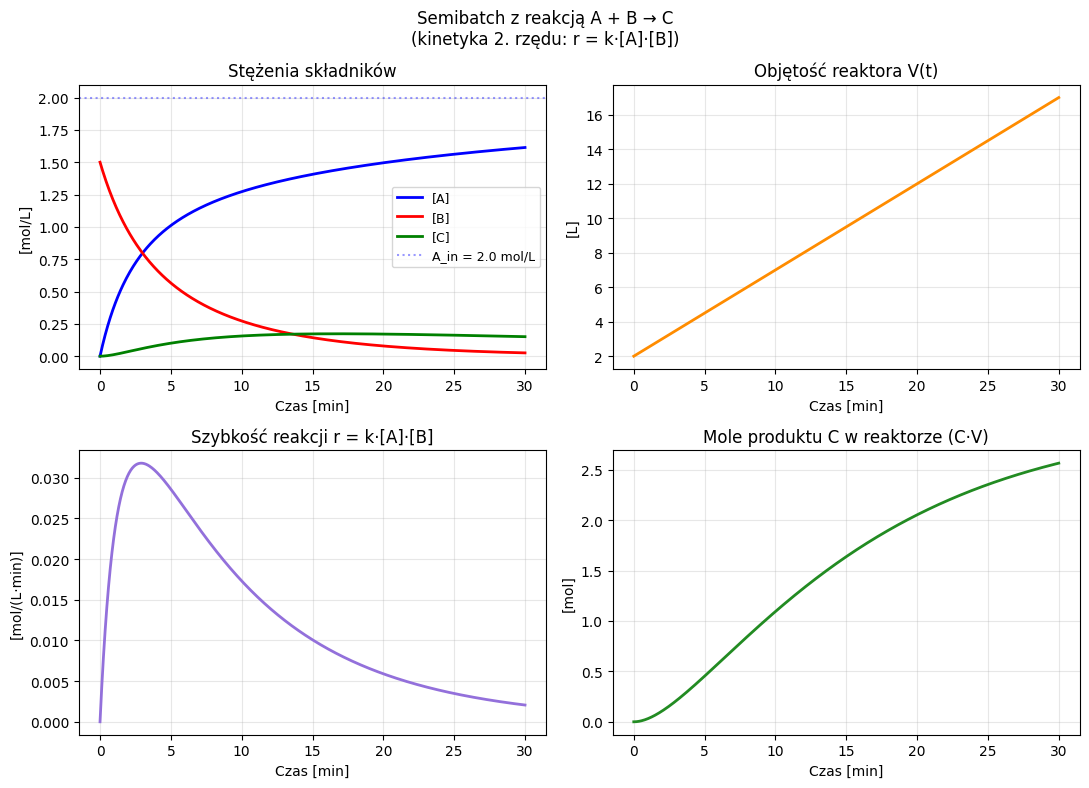

Wyniki po 30 min:
  [A] = 1.6138 mol/L
  [B] = 0.0255 mol/L
  [C] = 0.1509 mol/L
  V   = 17.00 L
  Mole C w reaktorze: 2.5659 mol
  Konwersja B: 98.3%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# --- Parametry ---
k    = 0.05   # [L/(mol·min)]  stała szybkości reakcji 2. rzędu
F    = 0.5    # [L/min]        natężenie zasilania (A w feed)
A_in = 2.0    # [mol/L]        stężenie A w zasilaniu

# Warunki początkowe w reaktorze
A0 = 0.0    # [mol/L]  brak A na starcie (A jest w feed)
B0 = 1.5    # [mol/L]  B jest w reaktorze od początku
C0 = 0.0    # [mol/L]  brak produktu na starcie
V0 = 2.0    # [L]      objętość początkowa roztworu w reaktorze


def model(y, t):
    A, B, C, V = y

    # szybkość reakcji [mol/(L·min)]
    r = k * A * B

    # szybkość rozcieńczenia [1/min]
    D = F / V

    dA_dt =  D * (A_in - A) - r   # A: wchodzi z feedem, zanika w reakcji
    dB_dt =  D * (0    - B) - r   # B: nie ma w feedzie, zanika w reakcji
    dC_dt =  D * (0    - C) + r   # C: nie ma w feedzie, powstaje w reakcji
    dV_dt =  F                     # objętość rośnie ze stałym F

    return [dA_dt, dB_dt, dC_dt, dV_dt]

t  = np.linspace(0, 30, 500)    # 0 - 30 min
y0 = [A0, B0, C0, V0]

wyniki = odeint(model, y0, t)


#--- odbróbka wyników

A = wyniki[:, 0]   # stężenie A [mol/L]
B = wyniki[:, 1]   # stężenie B [mol/L]
C = wyniki[:, 2]   # stężenie C [mol/L]
V = wyniki[:, 3]   # objętość   [L]

# pomocnicze obliczenia
# Szybkość reakcji w czasie (do wykresu)
r_t = k * A * B

# Mole produktu C w reaktorze (nie stężenie — prawdziwa ilość)
mol_C = C * V


# wizualizacja wyników
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle('Semibatch z reakcją A + B → C\n(kinetyka 2. rzędu: r = k·[A]·[B])')

# Stężenia A, B, C
axes[0, 0].plot(t, A, 'b-',  lw=2, label='[A]')
axes[0, 0].plot(t, B, 'r-',  lw=2, label='[B]')
axes[0, 0].plot(t, C, 'g-',  lw=2, label='[C]')
axes[0, 0].axhline(A_in, color='b', ls=':', alpha=0.4, label=f'A_in = {A_in} mol/L')
axes[0, 0].set_title('Stężenia składników')
axes[0, 0].set_ylabel('[mol/L]')
axes[0, 0].legend(fontsize=9)

# Objętość
axes[0, 1].plot(t, V, color='darkorange', lw=2)
axes[0, 1].set_title('Objętość reaktora V(t)')
axes[0, 1].set_ylabel('[L]')

# Szybkość reakcji r(t)
axes[1, 0].plot(t, r_t, color='mediumpurple', lw=2)
axes[1, 0].set_title('Szybkość reakcji r = k·[A]·[B]')
axes[1, 0].set_ylabel('[mol/(L·min)]')

# Mole produktu C w reaktorze
axes[1, 1].plot(t, mol_C, color='forestgreen', lw=2)
axes[1, 1].set_title('Mole produktu C w reaktorze (C·V)')
axes[1, 1].set_ylabel('[mol]')

for ax in axes.flat:
    ax.set_xlabel('Czas [min]')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Raport końcowy ---
print("Wyniki po 30 min:")
print(f"  [A] = {A[-1]:.4f} mol/L")
print(f"  [B] = {B[-1]:.4f} mol/L")
print(f"  [C] = {C[-1]:.4f} mol/L")
print(f"  V   = {V[-1]:.2f} L")
print(f"  Mole C w reaktorze: {mol_C[-1]:.4f} mol")
print(f"  Konwersja B: {(1 - B[-1]/B0)*100:.1f}%")

**Dlaczego [A] rośnie a potem się stabilizuje?**

Na początku procesu A wchodzi do reaktora — stężenie A jest bliskie zera, więc reakcja jest powolna (mały $r = k \cdot [A] \cdot [B]$). Z czasem [A] rośnie aż do stanu quasi-ustalonego, gdzie dopływ A przez feed równoważy jego zużycie w reakcji.

**Dlaczego [B] maleje monotonicznie?**

B nie jest dodawane — zanika przez reakcję i przez rozcieńczenie rosnącą objętością strumienia zasilającego. Oba efekty działają w tym samym kierunku (zmiejszają stężenie B).

**Dlaczego [C] ma maksimum albo plateau?**

C powstaje w reakcji, ale jest jednocześnie rozcieńczane rosnącą objętością. Wypadkowa zależy od tego który efekt dominuje.

**Kontekst bio:**
W fed-batchu biologicznym substrat $S$ gra rolę A (jest w feedzie), a biomasa $X$ gra rolę B (jest w reaktorze od początku i "reaguje" ze S). Produkt $P$ odpowiada C. Kinetyka jest inna (np. Monod zamiast $k \cdot A \cdot B$),
ale struktura równań i kod są identyczne.


### Zadanie 4 - wpływ stężenia A w zasilaniu

Porównaj trzy wartości $A_{in}$: `0.5`, `2.0`, `5.0` mol/L.
Jak zmienia się końcowa konwersja B i ilość moli C?

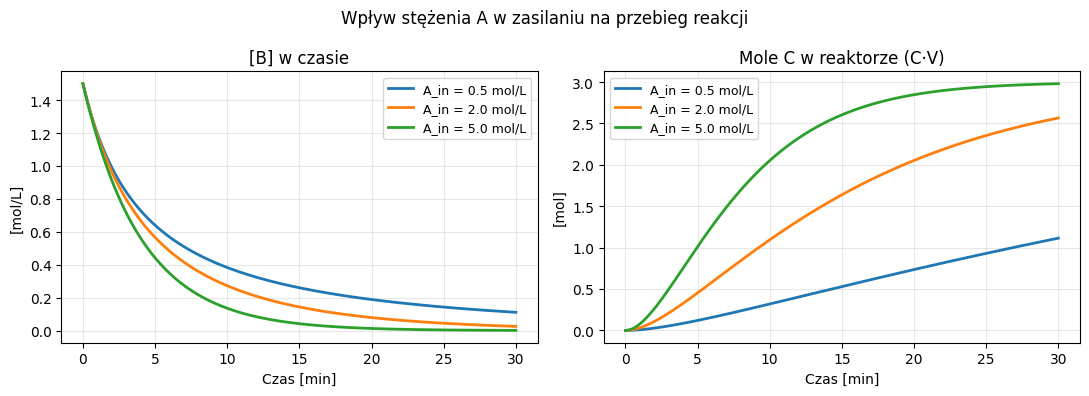

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Wpływ stężenia A w zasilaniu na przebieg reakcji')

for A_in_test in [0.5, 2.0, 5.0]:  ### obliczenia powtarzane dla różnych stężeń A w feed

    def model_test(y, t, A_in_val=A_in_test):
        A, B, C, V = y
        r    = k * A * B
        D    = F / V
        dA_dt =  D * (A_in_val - A) - r
        dB_dt =  D * (0 - B) - r
        dC_dt =  D * (0 - C) + r
        dV_dt =  F
        return [dA_dt, dB_dt, dC_dt, dV_dt]

    sol = odeint(model_test, y0, t)
    B_sol = sol[:, 1]
    C_sol = sol[:, 2]
    V_sol = sol[:, 3]

    axes[0].plot(t, B_sol, lw=2, label=f'A_in = {A_in_test} mol/L')
    axes[1].plot(t, C_sol * V_sol, lw=2, label=f'A_in = {A_in_test} mol/L')

axes[0].set_title('[B] w czasie')
axes[0].set_ylabel('[mol/L]')
axes[1].set_title('Mole C w reaktorze (C·V)')
axes[1].set_ylabel('[mol]')

for ax in axes:
    ax.set_xlabel('Czas [min]')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Zadanie 5 - wpływ natężenia przepływu F

Przy stałym $A_{in} = 2.0$ mol/L porównaj $F$: `0.1`, `0.5`, `1.5` L/min.
Wysoki F to więcej A dostarczonego — ale też szybsze rozcieńczenie B.
Czy zawsze opłaca się zwiększać F? Sprawdź wykres moli C. Zaproponuj "optymalny" F.

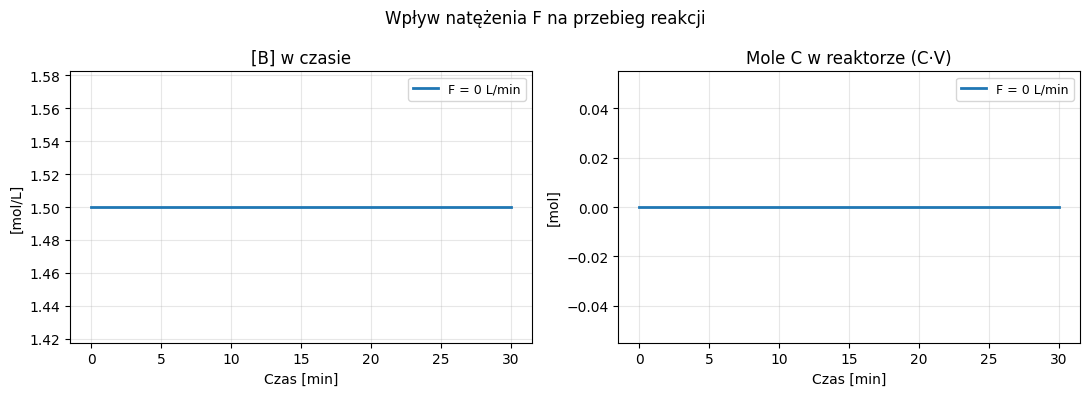

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Wpływ natężenia F na przebieg reakcji')

for F_test in [0]:  ### obliczenia powtarzane dla różnych F

    def model_F(y, t, F_val=F_test):
        A, B, C, V = y
        r     = k * A * B
        D     = F_val / V
        dA_dt =  D * (A_in - A) - r
        dB_dt =  D * (0 - B) - r
        dC_dt =  D * (0 - C) + r
        dV_dt =  F_val
        return [dA_dt, dB_dt, dC_dt, dV_dt]

    sol = odeint(model_F, y0, t)
    B_sol = sol[:, 1]
    C_sol = sol[:, 2]
    V_sol = sol[:, 3]

    axes[0].plot(t, B_sol, lw=2, label=f'F = {F_test} L/min')
    axes[1].plot(t, C_sol * V_sol, lw=2, label=f'F = {F_test} L/min')

axes[0].set_title('[B] w czasie')
axes[0].set_ylabel('[mol/L]')
axes[1].set_title('Mole C w reaktorze (C·V)')
axes[1].set_ylabel('[mol]')

for ax in axes:
    ax.set_xlabel('Czas [min]')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Semibatch bio: wzrost komórek na podłożu (kinetyka Monoda)

Poprzedni przykład: reakcja chemiczna A + B → C, $r = k \cdot [A] \cdot [B]$
Ten przykład: to samo, ale A to **substrat S**, B to **biomasa X**, a "reakcja" to **wzrost Monoda**


Porównanie chemia vs. biotechnologia

| Semibatch chemiczny | Semibatch biologiczny |
|:---:|:---:|
| A (w feedzie) | S — substrat (w feedzie) |
| B (w reaktorze) | X — biomasa (w reaktorze) |
| C (produkt) | — (na razie pomijamy) |
| $r = k \cdot [A][B]$ | $\mu = \mu_{max} \cdot \frac{S}{K_S + S}$ |

Kinetyka Monoda to **nasyceniowa** wersja kinetyki 2. rzędu:
- przy $S \ll K_S$: $\mu \approx \frac{\mu_{max}}{K_S} \cdot S$ — liniowa w S (jak 1. rzędu)
- przy $S \gg K_S$: $\mu \approx \mu_{max}$ — nasycenie, wzrost nie zależy od S



**Układ równań (model)**

Zmienne stanu: $X(t)$ [g/L], $S(t)$ [g/L], $V(t)$ [L]

Kinetyka Monoda:

$$\mu = \mu_{max} \cdot \frac{S}{K_S + S}$$

Bilanse masy na stężeniach:

$$\frac{dX}{dt} = \mu \cdot X - \frac{F}{V} \cdot X$$

$$\frac{dS}{dt} = \frac{F}{V}(S_{in} - S) - \frac{\mu}{Y_{XS}} \cdot X$$

$$\frac{dV}{dt} = F$$

**Człon $-\frac{F}{V} \cdot X$** to rozcieńczenie biomasy — komórek nie ubywa przez śmierć (w tym modelu),
ale rosnąca objętość "rozcieńcza" ich stężenie.

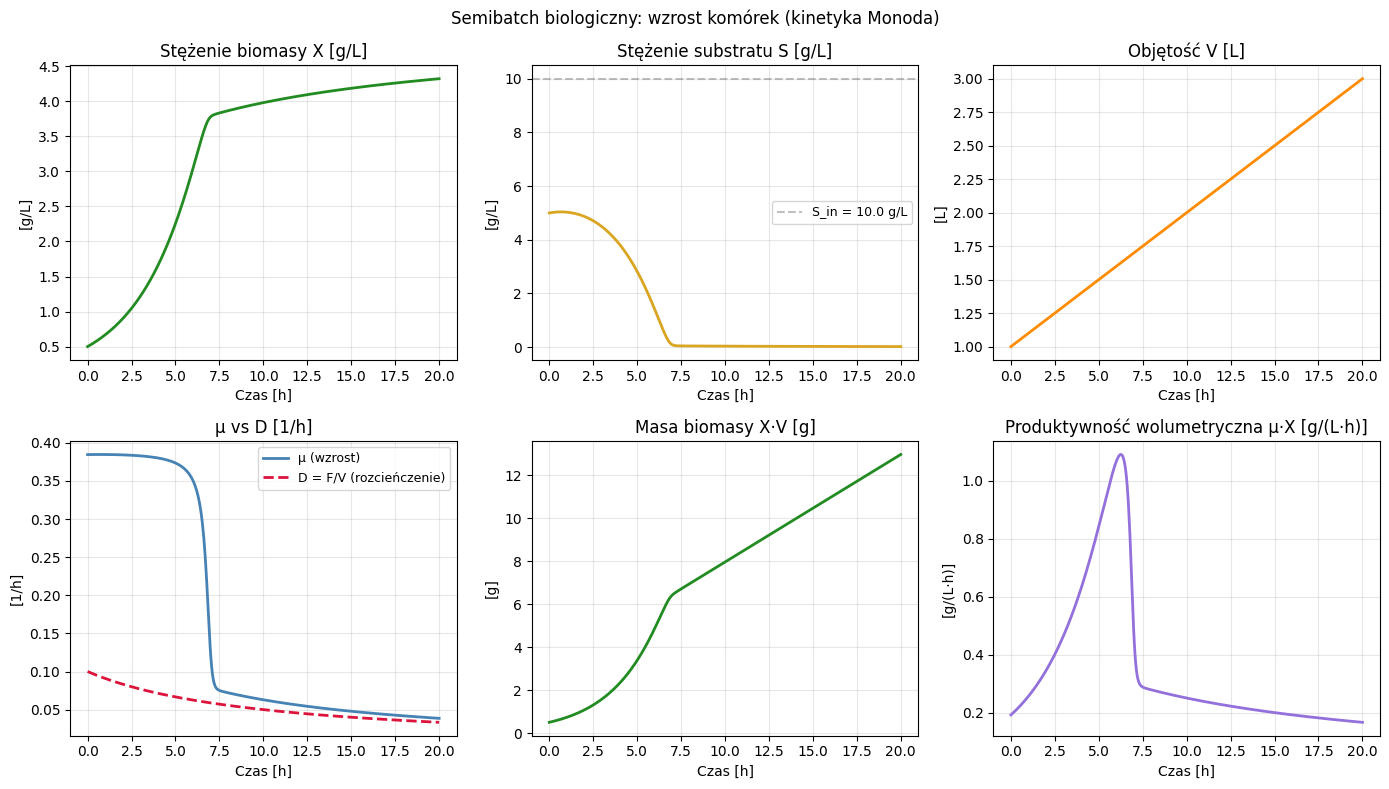

Wyniki po 20 h:
  X        = 4.323 g/L
  S        = 0.0213 g/L
  V        = 3.00 L
  X·V      = 12.968 g  (masa biomasy w reaktorze)
  μ końcowe = 0.0386 /h
  D końcowe = 0.0333 /h
  μ/D      = 1.16  (>1 → biomasa kumuluje się)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# --- Parametry biologiczne ---
mu_max = 0.4    # [1/h]    maksymalna szybkość wzrostu
K_S    = 0.2    # [g/L]    stała Monoda (przy S = K_S: mu = mu_max/2)
Y_XS   = 0.5    # [g/g]    wydajność: ile g biomasy z 1 g substratu

# --- Parametry procesu ---
F    = 0.1    # [L/h]   stały przepływ zasilania
S_in = 10.0   # [g/L]   stężenie substratu w feedzie

# --- Warunki początkowe ---
X0 = 0.5    # [g/L]  biomasa na starcie
S0 = 5.0    # [g/L]  substrat na starcie
V0 = 1.0    # [L]    objętość na starcie

# --- Model (układ ODE) ---
def model(y, t):
    X, S, V = y

    # kinetyka Monoda — zabezpieczenie przed S < 0
    S = max(S, 0.0)
    mu = mu_max * S / (K_S + S)

    # szybkość rozcieńczenia
    D = F / V

    dX_dt =  mu * X  -  D * X             # wzrost minus rozcieńczenie
    dS_dt =  D * (S_in - S)  -  (mu / Y_XS) * X   # feed minus zużycie
    dV_dt =  F

    return [dX_dt, dS_dt, dV_dt]

# --- Rozwiązanie ---
t  = np.linspace(0, 20, 500)    # 0 - 20 h
y0 = [X0, S0, V0]

wyniki = odeint(model, y0, t)

X  = wyniki[:, 0]   # biomasa [g/L]
S  = wyniki[:, 1]   # substrat [g/L]
V  = wyniki[:, 2]   # objętość [L]

# Wielkości pochodne
mu_t = mu_max * S / (K_S + S)   # szybkość wzrostu w czasie [1/h]
D_t  = F / V                     # szybkość rozcieńczenia w czasie [1/h]
X_m  = X * V                     # masa biomasy w reaktorze [g]

# --- Wykresy ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Semibatch biologiczny: wzrost komórek (kinetyka Monoda)')

# Biomasa X
axes[0, 0].plot(t, X, color='forestgreen', lw=2)
axes[0, 0].set_title('Stężenie biomasy X [g/L]')
axes[0, 0].set_ylabel('[g/L]')

# Substrat S
axes[0, 1].plot(t, S, color='goldenrod', lw=2)
axes[0, 1].axhline(S_in, color='gray', ls='--', alpha=0.5, label=f'S_in = {S_in} g/L')
axes[0, 1].set_title('Stężenie substratu S [g/L]')
axes[0, 1].set_ylabel('[g/L]')
axes[0, 1].legend(fontsize=9)

# Objętość
axes[0, 2].plot(t, V, color='darkorange', lw=2)
axes[0, 2].set_title('Objętość V [L]')
axes[0, 2].set_ylabel('[L]')

# mu vs D
axes[1, 0].plot(t, mu_t, color='steelblue', lw=2, label='μ (wzrost)')
axes[1, 0].plot(t, D_t,  color='crimson',   lw=2, ls='--', label='D = F/V (rozcieńczenie)')
axes[1, 0].set_title('μ vs D [1/h]')
axes[1, 0].set_ylabel('[1/h]')
axes[1, 0].legend(fontsize=9)

# Masa biomasy X·V
axes[1, 1].plot(t, X_m, color='forestgreen', lw=2)
axes[1, 1].set_title('Masa biomasy X·V [g]')
axes[1, 1].set_ylabel('[g]')

# Produktywność wolumetryczna μ·X
axes[1, 2].plot(t, mu_t * X, color='mediumpurple', lw=2)
axes[1, 2].set_title('Produktywność wolumetryczna μ·X [g/(L·h)]')
axes[1, 2].set_ylabel('[g/(L·h)]')

for ax in axes.flat:
    ax.set_xlabel('Czas [h]')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Raport końcowy ---
print("Wyniki po 20 h:")
print(f"  X        = {X[-1]:.3f} g/L")
print(f"  S        = {S[-1]:.4f} g/L")
print(f"  V        = {V[-1]:.2f} L")
print(f"  X·V      = {X_m[-1]:.3f} g  (masa biomasy w reaktorze)")
print(f"  μ końcowe = {mu_t[-1]:.4f} /h")
print(f"  D końcowe = {D_t[-1]:.4f} /h")
print(f"  μ/D      = {mu_t[-1]/D_t[-1]:.2f}  (>1 → biomasa kumuluje się)")

**Dlaczego X rośnie mimo rozcieńczenia?**

Dopóki $\mu > D$, wzrost jest szybszy niż rozcieńczenie — biomasa się kumuluje.
Z czasem $D = F/V$ maleje (V rośnie przy stałym F), więc rozcieńczenie staje się coraz mniejszym problemem.
To fundamentalna różnica między semibatch a chemostatem, gdzie $D = \text{const}$ i wymusza $\mu = D$.

**Dlaczego S spada do niskiego poziomu?**

Komórki zużywają substrat szybciej niż jest dostarczany przez feed.
Przy niskim S kinetyka Monoda ogranicza μ — to jest właśnie **kontrola przez substrat**,
cel prowadzenia procesu fed-batch.

**Co oznacza wykres μ vs D?**

- $\mu > D$ → biomasa rośnie (stężenie X wzrasta)
- $\mu = D$ → stan ustalony (chemostat)
- $\mu < D$ → biomasa jest wypłukiwana (washout)

W semibatch D maleje monotoniczne — nie ma ryzyka wypłukania po uruchomieniu feedu.

### Zadanie 6 - wpływ stężenia substratu w feedzie

Porównaj $S_{in}$: `2.0`, `10.0`, `50.0` g/L przy stałym F.
Wyższe $S_{in}$ to więcej substratu dostarczonego — ale czy zawsze
przekłada się na wyższą masę końcową biomasy? Sprawdź wykres X·V. Dodaj wykres V(t).

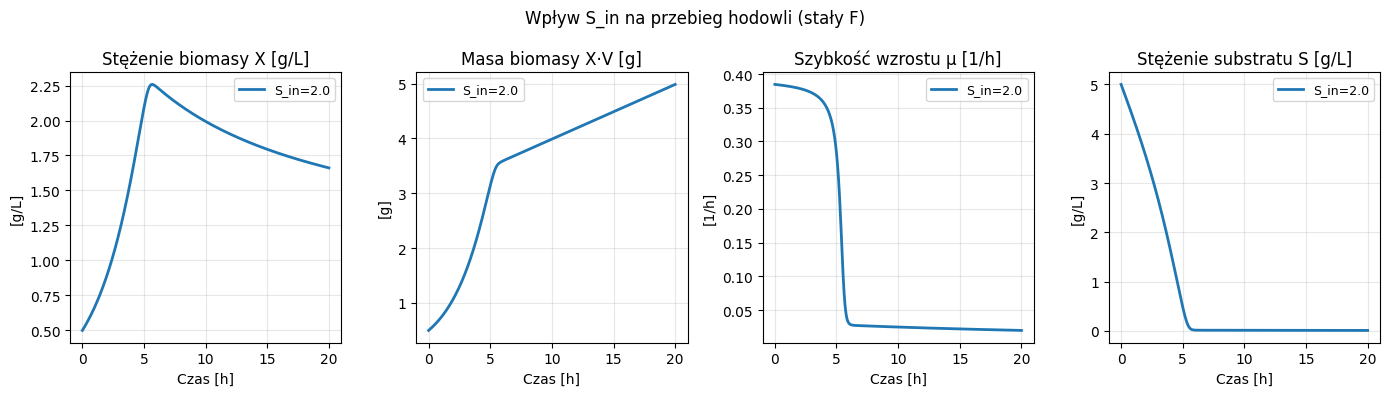

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Wpływ S_in na przebieg hodowli (stały F)')

# --- Parametry biologiczne ---
mu_max = 0.4    # [1/h]    maksymalna szybkość wzrostu
K_S    = 0.2    # [g/L]    stała Monoda (przy S = K_S: mu = mu_max/2)
Y_XS   = 0.5    # [g/g]    wydajność: ile g biomasy z 1 g substratu

# --- Parametry procesu ---
F    = 0.1    # [L/h]   stały przepływ zasilania
S_in = 10.0   # [g/L]   stężenie substratu w feedzie

# --- Warunki początkowe ---
X0 = 0.5    # [g/L]  biomasa na starcie
S0 = 5.0    # [g/L]  substrat na starcie
V0 = 1.0    # [L]    objętość na starcie


for S_in_test in [2.0]: # testowane wartości

    def model_Sin(y, t, Sin=S_in_test):
        X, S, V = y
        S = max(S, 0.0)
        mu = mu_max * S / (K_S + S)
        D  = F / V
        return [mu*X - D*X,
                D*(Sin - S) - (mu/Y_XS)*X,
                F]

    sol = odeint(model_Sin, y0, t)
    X_s = sol[:, 0]
    S_s = sol[:, 1]
    V_s = sol[:, 2]
    mu_s = mu_max * S_s / (K_S + S_s)

    axes[0].plot(t, X_s,       lw=2, label=f'S_in={S_in_test}')
    axes[1].plot(t, X_s * V_s, lw=2, label=f'S_in={S_in_test}')
    axes[2].plot(t, mu_s,      lw=2, label=f'S_in={S_in_test}')
    axes[3].plot(t, S_s,      lw=2, label=f'S_in={S_in_test}')

tytuly  = ['Stężenie biomasy X [g/L]', 'Masa biomasy X·V [g]', 'Szybkość wzrostu μ [1/h]', 'Stężenie substratu S [g/L]']
ylabels = ['[g/L]', '[g]', '[1/h]', '[g/L]']
for ax, tyt, ylab in zip(axes, tytuly, ylabels):
    ax.set_title(tyt)
    ax.set_ylabel(ylab)
    ax.set_xlabel('Czas [h]')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Zadanie 7 - wpływ natężenia strumienia zasilającego F

Porównaj $F$: `0.05`, `0.1`, `0.3` L/h przy stałym $S_{in} = 10$ g/L.

Wyższy F dostarcza więcej substratu - ale też mocniej rozcieńcza X. Przy jakim F masa biomasy X·V jest największa po 20 h? Dodaj wykres V(t).

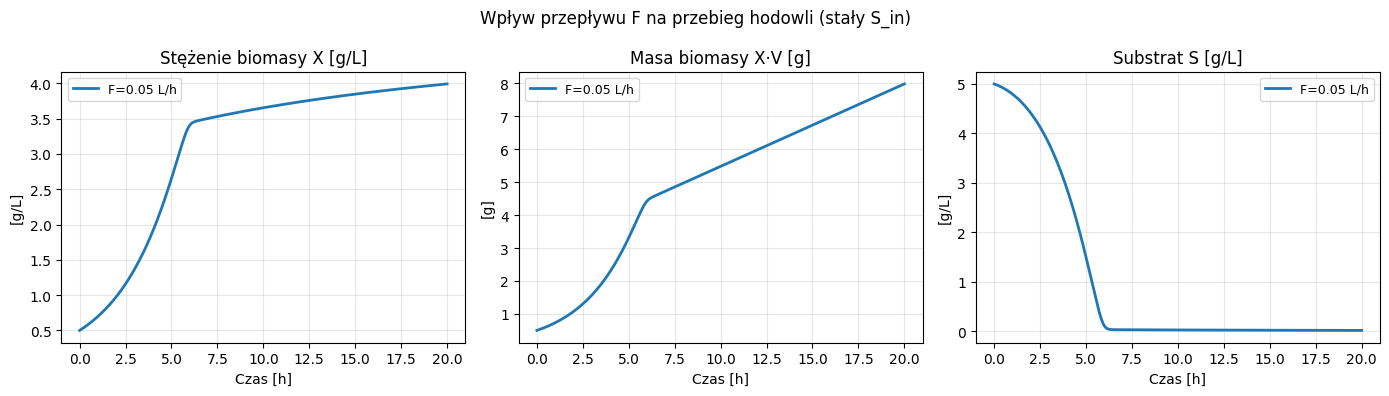

In [ ]:
# --- Parametry biologiczne ---
mu_max = 0.4    # [1/h]    maksymalna szybkość wzrostu
K_S    = 0.2    # [g/L]    stała Monoda (przy S = K_S: mu = mu_max/2)
Y_XS   = 0.5    # [g/g]    wydajność: ile g biomasy z 1 g substratu

# --- Parametry procesu ---
F    = 0.1    # [L/h]   stały przepływ zasilania
S_in = 10.0   # [g/L]   stężenie substratu w feedzie

# --- Warunki początkowe ---
X0 = 0.5    # [g/L]  biomasa na starcie
S0 = 5.0    # [g/L]  substrat na starcie
V0 = 1.0    # [L]    objętość na starcie

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Wpływ przepływu F na przebieg hodowli (stały S_in)')

for F_test in [0.05]:

    def model_F(y, t, Fv=F_test):
        X, S, V = y
        S = max(S, 0.0)
        mu = mu_max * S / (K_S + S)
        D  = Fv / V
        return [mu*X - D*X,
                D*(S_in - S) - (mu/Y_XS)*X,
                Fv]

    sol = odeint(model_F, y0, t)
    X_f  = sol[:, 0]
    S_f  = sol[:, 1]
    V_f  = sol[:, 2]
    D_f  = F_test / V_f

    axes[0].plot(t, X_f,       lw=2, label=f'F={F_test} L/h')
    axes[1].plot(t, X_f * V_f, lw=2, label=f'F={F_test} L/h')
    axes[2].plot(t, S_f,       lw=2, label=f'F={F_test} L/h')

tytuly  = ['Stężenie biomasy X [g/L]', 'Masa biomasy X·V [g]', 'Substrat S [g/L]']
ylabels = ['[g/L]', '[g]', '[g/L]']
for ax, tyt, ylab in zip(axes, tytuly, ylabels):
    ax.set_title(tyt)
    ax.set_ylabel(ylab)
    ax.set_xlabel('Czas [h]')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Semibatch vs Batch: inhibicja substratem (kinetyka Haldane'a)

**Główny powód stosowania semibatch w przemyśle**: gdy substrat w wysokim stężeniu **hamuje wzrost komórek**. W semibatch dodajemy substrat **odpowiednio** powoli — utrzymujemy jego stężenie na niskim, bezpiecznym poziomie (nie powodującym inhibicji).

**Kinetyka Haldane'a (inhibicja substratem)**

Kinetyka Monoda zakłada, że im więcej substratu tym lepiej (do nasycenia).
Kinetyka Haldane'a dodaje człon hamujący przy wysokich stężeniach S:

$$\mu = \mu_{max} \cdot \frac{S}{K_S + S + \frac{S^2}{K_I}}$$

Istnieje optimum stężenia substratu $S^*$. Poniżej $S^*$: wolny wzrost. Powyżej $S^*$: za duże stężenie S → inhibicja → jeszcze wolniejszy wzrost.

Optimum obliczamy analitycznie z warunku $\frac{d\mu}{dS} = 0$:

$$S^* = \sqrt{K_S \cdot K_I}$$

$$\mu^* = \mu_{max} \cdot \frac{S^*}{K_S + S^* + \frac{S^{*2}}{K_I}}$$




Optimum stężenia substratu: S* = 1.581 g/L
Maksymalne mu przy S*:      μ* = 0.306 1/h
(mu_max teoretyczne:        0.500 1/h — nigdy nieosiągalne przy inhibicji)


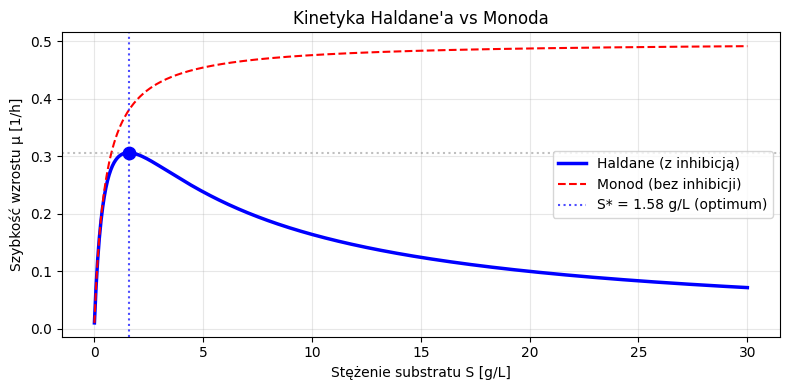

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# --- Parametry kinetyczne ---
mu_max = 0.5    # [1/h]   maksymalna szybkość wzrostu (teoretyczna)
K_S    = 0.5    # [g/L]   stała powinowactwa (jak w Monodzie)
K_I    = 5.0    # [g/L]   stała inhibicji (im mniejsze, tym silniejsza inhibicja)
Y_XS   = 0.4    # [g/g]   wydajność biomasy na substrat

# --- Optimum substratu ---
S_opt = np.sqrt(K_S * K_I)
mu_opt = mu_max * S_opt / (K_S + S_opt + S_opt**2 / K_I)

print(f"Optimum stężenia substratu: S* = {S_opt:.3f} g/L")
print(f"Maksymalne mu przy S*:      μ* = {mu_opt:.3f} 1/h")
print(f"(mu_max teoretyczne:        {mu_max:.3f} 1/h — nigdy nieosiągalne przy inhibicji)")

# --- Wykres kinetyki ---
S_range = np.linspace(0.01, 30, 400)
mu_haldane = mu_max * S_range / (K_S + S_range + S_range**2 / K_I)
mu_monod   = mu_max * S_range / (K_S + S_range)   # dla porównania

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(S_range, mu_haldane, 'b-',  lw=2.5, label='Haldane (z inhibicją)')
ax.plot(S_range, mu_monod,   'r--', lw=1.5, label='Monod (bez inhibicji)')
ax.axvline(S_opt, color='b', ls=':', alpha=0.7, label=f'S* = {S_opt:.2f} g/L (optimum)')
ax.axhline(mu_opt, color='gray', ls=':', alpha=0.5)
ax.scatter([S_opt], [mu_opt], color='b', s=80, zorder=5)
ax.set_xlabel('Stężenie substratu S [g/L]')
ax.set_ylabel('Szybkość wzrostu μ [1/h]')
ax.set_title('Kinetyka Haldane\'a vs Monoda')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Łączny substrat — batch:    40.0 g
Łączny substrat — semibatch: 21.0 g


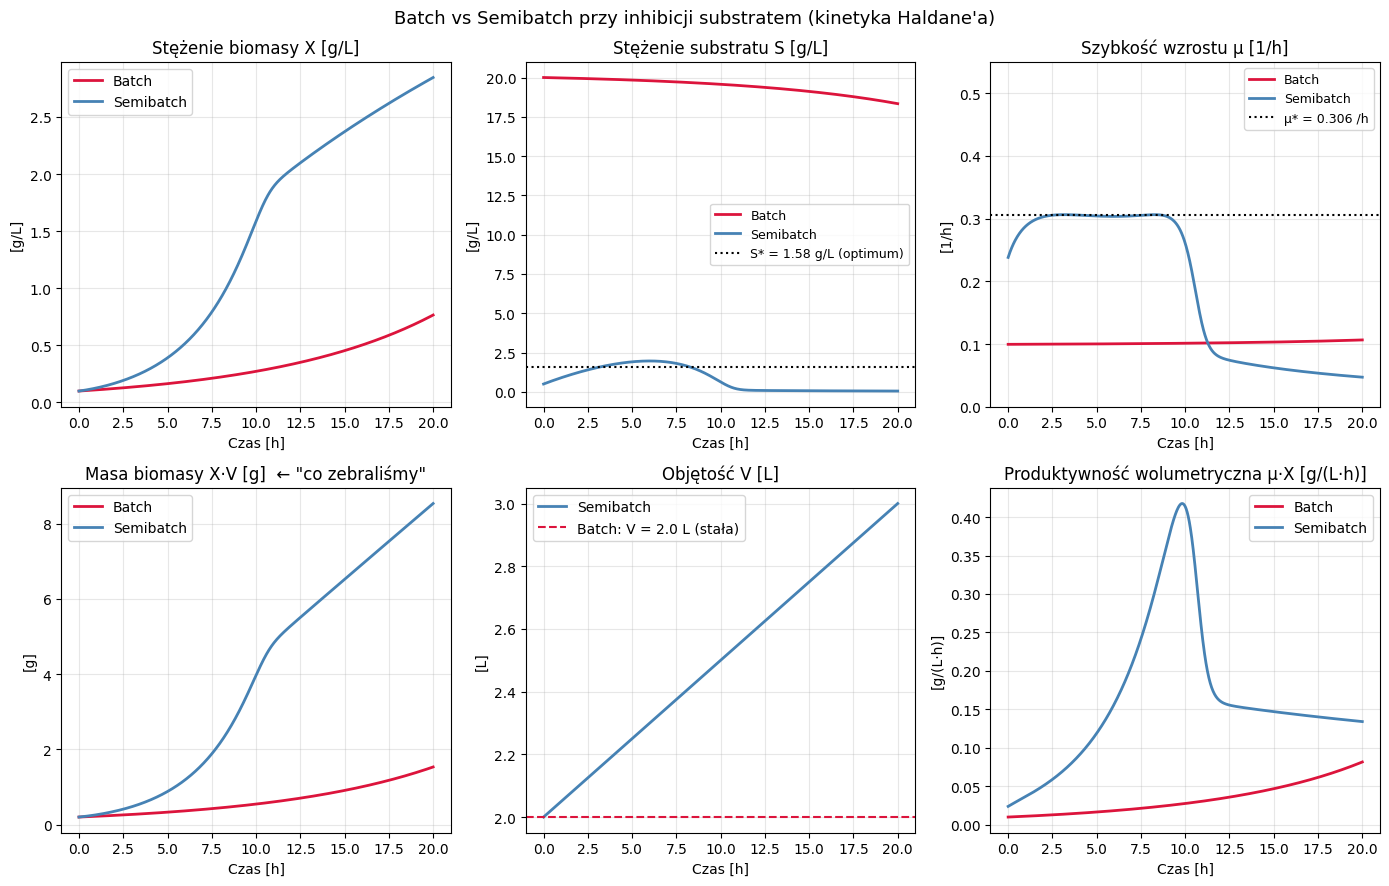


──────────────────────────────────────────────────
WYNIK PO 20 H                     BATCH  SEMIBATCH
──────────────────────────────────────────────────
X [g/L]                           0.766      2.846
S [g/L]                         18.3355     0.0521
X·V [g] (masa biomasy)            1.532      8.538
μ końcowe [1/h]                  0.1065     0.0471
──────────────────────────────────────────────────
Semibatch zebrał 5.6x więcej biomasy niż batch


In [ ]:
# --- Parametry procesu ---
S0_batch   = 20.0   # [g/L]  stężenie substratu w batch
X0         = 0.1    # [g/L]  biomasa na starcie (inokolum)
V0         = 2.0    # [L]    objętość początkowa

# Semibatch: startujemy z niskim S, dolewamy powoli
S0_semi    = 0.5    # [g/L]  niskie S na starcie — poniżej optimum
F          = 0.05   # [L/h]  mały, stały przepływ
S_in       = 20.0   # [g/L]  koncentrat substratu w feedzie

# Ten sam łączny substrat w obu przypadkach?
# Batch:     S0_batch * V0            = 20 * 2 = 40 g substratu
# Semibatch: S0_semi * V0 + S_in * F * t_end
t_end = 20.0   # [h]
t = np.linspace(0, t_end, 1000)

masa_batch = S0_batch * V0
masa_semi  = S0_semi * V0 + S_in * F * t_end
print(f"\nŁączny substrat — batch:    {masa_batch:.1f} g")
print(f"Łączny substrat — semibatch: {masa_semi:.1f} g")

# --- Funkcja kinetyki Haldane'a ---
def mu_haldane(S):
    S = max(S, 0.0)
    return mu_max * S / (K_S + S + S**2 / K_I)

# --- Model BATCH ---
def model_batch(y, t):
    X, S = y
    mu = mu_haldane(S)
    dX_dt = mu * X
    dS_dt = -(mu / Y_XS) * X
    return [dX_dt, dS_dt]

sol_batch = odeint(model_batch, [X0, S0_batch], t)
X_b = sol_batch[:, 0]
S_b = sol_batch[:, 1]
mu_b = np.array([mu_haldane(s) for s in S_b])

# --- Model SEMIBATCH ---
def model_semi(y, t):
    X, S, V = y
    mu = mu_haldane(S)
    D  = F / V
    dX_dt =  mu * X  -  D * X
    dS_dt =  D * (S_in - S)  -  (mu / Y_XS) * X
    dV_dt =  F
    return [dX_dt, dS_dt, dV_dt]

sol_semi = odeint(model_semi, [X0, S0_semi, V0], t)
X_s  = sol_semi[:, 0]
S_s  = sol_semi[:, 1]
V_s  = sol_semi[:, 2]
mu_s = np.array([mu_haldane(s) for s in S_s])

# Masy biomasy
Xm_b = X_b * V0          # batch: V = const
Xm_s = X_s * V_s         # semibatch: V rośnie

# --- Wykresy porównawcze ---
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('Batch vs Semibatch przy inhibicji substratem (kinetyka Haldane\'a)',
             fontsize=13)

kolor_b = 'crimson'
kolor_s = 'steelblue'

# Biomasa X [g/L]
axes[0, 0].plot(t, X_b, color=kolor_b, lw=2, label='Batch')
axes[0, 0].plot(t, X_s, color=kolor_s, lw=2, label='Semibatch')
axes[0, 0].set_title('Stężenie biomasy X [g/L]')
axes[0, 0].set_ylabel('[g/L]')
axes[0, 0].legend()

# Substrat S [g/L]
axes[0, 1].plot(t, S_b, color=kolor_b, lw=2, label='Batch')
axes[0, 1].plot(t, S_s, color=kolor_s, lw=2, label='Semibatch')
axes[0, 1].axhline(S_opt, color='k', ls=':', lw=1.5, label=f'S* = {S_opt:.2f} g/L (optimum)')
axes[0, 1].set_title('Stężenie substratu S [g/L]')
axes[0, 1].set_ylabel('[g/L]')
axes[0, 1].legend(fontsize=9)

# Szybkość wzrostu μ [1/h]
axes[0, 2].plot(t, mu_b, color=kolor_b, lw=2, label='Batch')
axes[0, 2].plot(t, mu_s, color=kolor_s, lw=2, label='Semibatch')
axes[0, 2].axhline(mu_opt, color='k', ls=':', lw=1.5, label=f'μ* = {mu_opt:.3f} /h')
axes[0, 2].set_title('Szybkość wzrostu μ [1/h]')
axes[0, 2].set_ylabel('[1/h]')
axes[0, 2].set_ylim(0, mu_max * 1.1)
axes[0, 2].legend(fontsize=9)

# Masa biomasy X·V [g]
axes[1, 0].plot(t, Xm_b, color=kolor_b, lw=2, label='Batch')
axes[1, 0].plot(t, Xm_s, color=kolor_s, lw=2, label='Semibatch')
axes[1, 0].set_title('Masa biomasy X·V [g]  ← "co zebraliśmy"')
axes[1, 0].set_ylabel('[g]')
axes[1, 0].legend()

# Objętość (tylko semibatch)
axes[1, 1].plot(t, V_s, color=kolor_s, lw=2, label='Semibatch')
axes[1, 1].axhline(V0, color=kolor_b, ls='--', lw=1.5, label=f'Batch: V = {V0} L (stała)')
axes[1, 1].set_title('Objętość V [L]')
axes[1, 1].set_ylabel('[L]')
axes[1, 1].legend()

# Produktywność wolumetryczna μ·X
axes[1, 2].plot(t, mu_b * X_b, color=kolor_b, lw=2, label='Batch')
axes[1, 2].plot(t, mu_s * X_s, color=kolor_s, lw=2, label='Semibatch')
axes[1, 2].set_title('Produktywność wolumetryczna μ·X [g/(L·h)]')
axes[1, 2].set_ylabel('[g/(L·h)]')
axes[1, 2].legend()

for ax in axes.flat:
    ax.set_xlabel('Czas [h]')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Raport końcowy ---
print("\n" + "─" * 50)
print(f"{'WYNIK PO 20 H':<30} {'BATCH':>8} {'SEMIBATCH':>10}")
print("─" * 50)
print(f"{'X [g/L]':<30} {X_b[-1]:>8.3f} {X_s[-1]:>10.3f}")
print(f"{'S [g/L]':<30} {S_b[-1]:>8.4f} {S_s[-1]:>10.4f}")
print(f"{'X·V [g] (masa biomasy)':<30} {Xm_b[-1]:>8.3f} {Xm_s[-1]:>10.3f}")
print(f"{'μ końcowe [1/h]':<30} {mu_b[-1]:>8.4f} {mu_s[-1]:>10.4f}")
print("─" * 50)
print(f"Semibatch zebrał {Xm_s[-1]/Xm_b[-1]:.1f}x więcej biomasy niż batch")


**Co się dzieje w batchу na starcie?**

$S_0 = 20$ g/L to ponad $3 \times S^*$ (optimum). Komórki są silnie zahamowane — μ na starcie
jest bardzo niskie. Dopiero gdy substrat spadnie do okolic $S^*$, wzrost przyspiesza.
Ale wtedy substratu już mało — krótkie okno szybkiego wzrostu, potem głodzenie.

**Co się dzieje w semibatch?**

Startujemy z $S_0 = 0.5$ g/L — blisko optimum $S^*$.
Feed powoli dostarcza substrat, utrzymując $S$ w pobliżu $S^*$ przez cały czas procesu.
Komórki rosną blisko $\mu^*$ przez większość czasu hodowli.

**Dlaczego stężenie X w semibatch może być niższe niż w batchу, a masa X·V wyższa?**

Bo objętość w semibatch rośnie — efekt rozcieńczenia obniża stężenie,
ale masa (X·V) jest miarą rzeczywistej ilości komórek w reaktorze.
**Zawsze patrz na masę, nie stężenie, gdy oceniasz wydajność fed-batchu.**


**Polecenie 1.**
Zmień `S0_batch` na `2.0` g/L (blisko $S^*$).
Co się dzieje z przewagą semibatch?
Kiedy batch *nie* potrzebuje semibatch?

**Polecenie 2.**
Ustaw `K_I = 100.0` g/L (bardzo słaba inhibicja — prawie Monod).
Porównaj wykresy z oryginałem.
Jaki jest próg $K_I$ poniżej którego semibatch przestaje mieć sens?

**Polecenie 3.**
Wypisz w którym momencie czasu $\mu$ w batchu osiąga maksimum.
Czy pokrywa się z momentem gdy $S = S^*$?
Sprawdź na wykresie.